<a href="https://colab.research.google.com/github/Dhanshree010/Machine-Vision-Practical/blob/main/practical4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving metal.jpg to metal (1).jpg
Machine Vision Inspection Report
Total Defects Detected : 2


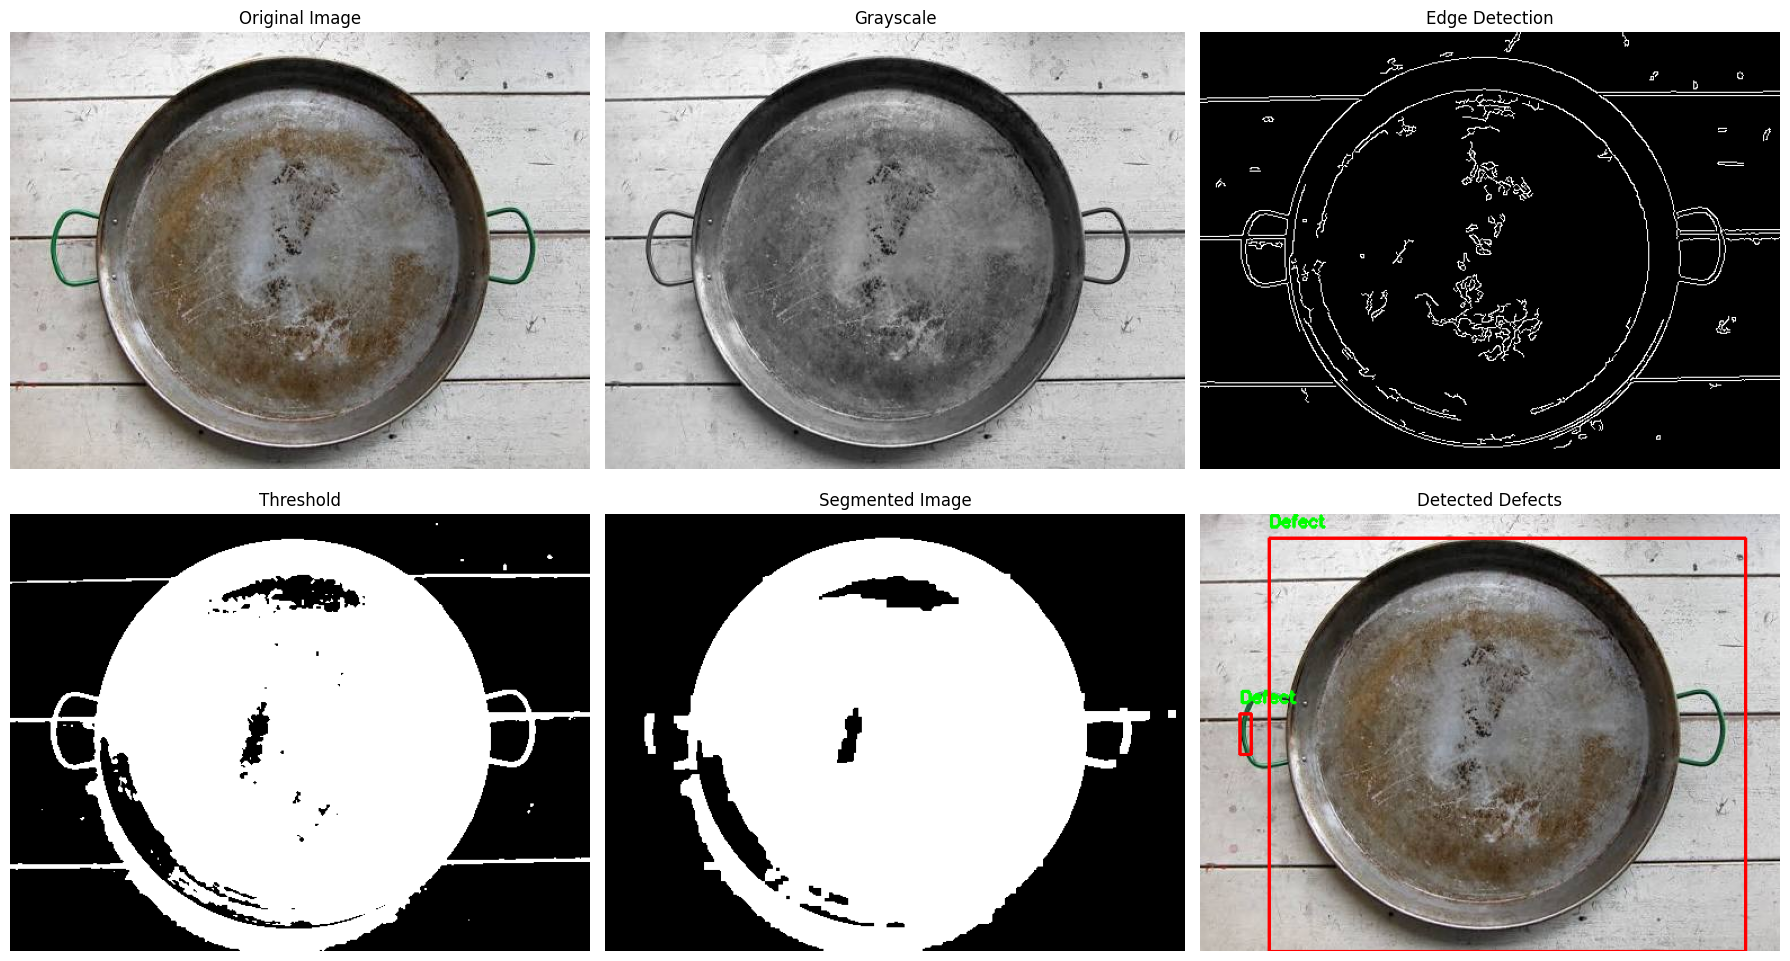


Detected Defects Image:



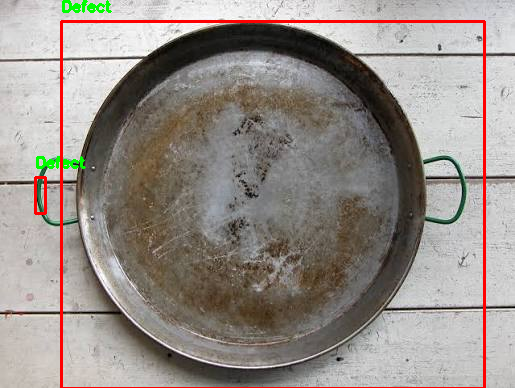

Output saved as: Detected_Defects.jpg


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# ==========================================================
# Machine Vision: Scratch and Crack Detection on Metal Surface
# Google Colab Compatible
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

# ----------------------------------------------------------
# Step 1: Upload Image
# ----------------------------------------------------------
uploaded = files.upload()

# Get uploaded filename
filename = list(uploaded.keys())[0]

# Read image
image = cv2.imread(filename)

if image is None:
    print("Error: Unable to load image.")
    exit()

original = image.copy()

# ----------------------------------------------------------
# Step 2: Convert to Grayscale
# ----------------------------------------------------------
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# ----------------------------------------------------------
# Step 3: Gaussian Blur (Noise Removal)
# ----------------------------------------------------------
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# ----------------------------------------------------------
# Step 4: Edge Detection
# ----------------------------------------------------------
edges = cv2.Canny(blur, 50, 150)

# ----------------------------------------------------------
# Step 5: Thresholding (Otsu)
# ----------------------------------------------------------
_, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# ----------------------------------------------------------
# Step 6: Morphological Operations
# ----------------------------------------------------------
kernel = np.ones((3, 3), np.uint8)

# Remove small noise
opening = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

# Connect broken defects
closing = cv2.morphologyEx(
    opening,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

# Expand defect regions
segmented = cv2.dilate(
    closing,
    kernel,
    iterations=1
)

# ----------------------------------------------------------
# Step 7: Contour Extraction
# ----------------------------------------------------------
contours, _ = cv2.findContours(
    segmented,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# ----------------------------------------------------------
# Step 8: Detect Defects
# ----------------------------------------------------------
defect_count = 0

for contour in contours:

    area = cv2.contourArea(contour)

    # Ignore very small regions
    if area > 50:

        defect_count += 1

        x, y, w, h = cv2.boundingRect(contour)

        cv2.rectangle(
            original,
            (x, y),
            (x + w, y + h),
            (0, 0, 255),
            2
        )

        cv2.putText(
            original,
            "Defect",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )

print("====================================")
print("Machine Vision Inspection Report")
print("====================================")
print("Total Defects Detected :", defect_count)
print("====================================")

# ----------------------------------------------------------
# Step 9: Display Results
# ----------------------------------------------------------
titles = [
    "Original Image",
    "Grayscale",
    "Edge Detection",
    "Threshold",
    "Segmented Image",
    "Detected Defects"
]

images = [
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    gray,
    edges,
    thresh,
    segmented,
    cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
]

plt.figure(figsize=(18,10))

for i in range(6):

    plt.subplot(2,3,i+1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap='gray')
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Step 10: Display Using OpenCV (Colab Compatible)
# ----------------------------------------------------------
print("\nDetected Defects Image:\n")
cv2_imshow(original)

# ----------------------------------------------------------
# Step 11: Save Output
# ----------------------------------------------------------
output_name = "Detected_Defects.jpg"
cv2.imwrite(output_name, original)

print("Output saved as:", output_name)

# ----------------------------------------------------------
# Step 12: Download Output Image
# ----------------------------------------------------------
files.download(output_name)